# **Clasificador de imágenes: Modelo 1**
---

Autores: Andrés Barroso Soriano y Paula Santana García

Universidad de Las Palmas de Gran Canaria, Curso 2025 - 2026


#### **1. INTRODUCCIÓN**

En esta práctica vamos a desarrollar una red neuronal para la clasificación de un conjunto de imágenes de piezas de ajedrez. Nuestro dataset cuenta con seis clases llamadas: “Bishop”, “Pawn”, “Rook”, “Queen”, “King” y “Knight”. En total contamos con 651 imágenes, de las cuales 455 son para entrenamiento, 65 para validación y 131 de prueba.

#### **2. IMPORTACIONES**
En esta primera parte realizamos las importaciones necesarias.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import os, zipfile
from google.colab import files
import random
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#### **3. SEMILLA**
La función "seed_everything(seed)" se encarga de fijar una semilla para que los experimentos sean reproducibles. De esta forma obtenemos resultados que nos permiten comparar modelos de forma justa.

In [ ]:
def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
    random.seed(seed)

seed_everything(42)

#### **4. DATASET Y TRANSFORMACIONES**
A continuación subimos y extraemos el dataset y realizamos las transformaciones necesarias:

Resize: Todas las imágenes se redimensionan a 128x128 píxeles, para que todas tengan el mismo tamaño y puedan ser procesadas por la red.

ToTensor: Convierte las imágenes en tensores de PyTorch, que son la estructura de datos que la red necesita.

Normalize: Ajusta los valores de los píxeles para que tengan media 0.5 y desviación estándar 0.5. Esto ayuda a que la red aprenda más rápido y evita problemas de gradientes.

In [ ]:
# =============================
# SUBIR Y EXTRAER DATASET
# =============================
uploaded = files.upload()
with zipfile.ZipFile("dataset4.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset4")

# =============================
# TRANSFORMACIONES DE LAS IMÁGENES
# =============================
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Saving dataset4.zip to dataset4 (1).zip


#### **5. CARGA Y DIVISIÓN DEL DATASET**
Cargamos y dividimos el dataset en 70% entrenamiento, 10% validación, 20% test. Esto permite entrenar la red, ajustar hiperparámetros y evaluar su desempeño final sin sesgo.

In [ ]:
# =============================
# Cargar todo el dataset
# =============================
dataset = datasets.ImageFolder(root="dataset4/dataset4", transform=transform)

# División del dataset
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

# =============================
# DATALOADERS
# =============================
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"Total imágenes: {len(dataset)}")
print(f"Entrenamiento: {len(train_data)}")
print(f"Validación: {len(val_data)}")
print(f"Prueba: {len(test_data)}")
print(f"Clases: {dataset.classes}")

Total imágenes: 651
Entrenamiento: 455
Validación: 65
Prueba: 131
Clases: ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']


#### **6. RED NEURONAL**
Definimos nuestra red neuronal que cuenta con:
* 2 capas convolutivas: extraen características locales (bordes, formas, texturas).

* MaxPooling: reduce el tamaño espacial a la mitad, conservando las características más importantes.

* 2 capas lineales (fully connected): interpretan las características extraídas y hacen la clasificación.

* 6 neuronas en la salida: una por cada clase del dataset (Bishop, King, Knight, Pawn, Queen, Rook).

In [ ]:
# =============================
# DEFINICIÓN DE LA RED NEURONAL
# =============================
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 5, padding=2)
        self.fc1 = nn.Linear(32 * 32 * 32, 120)
        self.fc2 = nn.Linear(120, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


#### **7. CONFIGURACIÓN DEL ENTRENAMIENTO**
Configuramos el entrenamiento para que seleccione GPU si está disponible, y si no CPU, ya que las operaciones se realizan más rápido en GPU.
También definimos la función de pérdida y optimizador:

**nn.CrossEntropyLoss()**

* Se usa para clasificación multiclase.

* Combina Softmax y Log Loss internamente.

* Compara las predicciones de la red con las etiquetas verdaderas.

**optim.Adam(...)**

* Adam es un optimizador que ajusta los pesos de la red automáticamente.

* Usa gradientes acumulados y tasas de aprendizaje adaptativas.

* lr=0.001 es la tasa de aprendizaje inicial.


In [ ]:
# =============================
# CONFIGURACIÓN DEL ENTRENAMIENTO
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### **8. ENTRENAMIENTO**
Comenzamos el entrenamiento creando las variables para almacenar resultados y realizamos un bucle que entrena por batch para finalmente calcular el accuracy de entrenamiento.

In [ ]:

# =============================
# ENTRENAMIENTO
# =============================
epochs = 20
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    # ----- Entrenamiento -----
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----- Validación -----
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch [1/20] - Train Loss: 1.9332, Train Acc: 18.02% | Val Loss: 1.7968, Val Acc: 29.23%
Epoch [2/20] - Train Loss: 1.7872, Train Acc: 17.36% | Val Loss: 1.7871, Val Acc: 26.15%
Epoch [3/20] - Train Loss: 1.7472, Train Acc: 24.40% | Val Loss: 1.7080, Val Acc: 35.38%
Epoch [4/20] - Train Loss: 1.5937, Train Acc: 34.29% | Val Loss: 1.5683, Val Acc: 32.31%
Epoch [5/20] - Train Loss: 1.2140, Train Acc: 52.97% | Val Loss: 1.5386, Val Acc: 41.54%
Epoch [6/20] - Train Loss: 0.8220, Train Acc: 69.01% | Val Loss: 1.7243, Val Acc: 35.38%
Epoch [7/20] - Train Loss: 0.5563, Train Acc: 80.22% | Val Loss: 1.9353, Val Acc: 33.85%
Epoch [8/20] - Train Loss: 0.3238, Train Acc: 88.13% | Val Loss: 1.9872, Val Acc: 41.54%
Epoch [9/20] - Train Loss: 0.1904, Train Acc: 94.29% | Val Loss: 2.3547, Val Acc: 44.62%
Epoch [10/20] - Train Loss: 0.1274, Train Acc: 97.14% | Val Loss: 2.6210, Val Acc: 43.08%
Epoch [11/20] - Train Loss: 0.1088, Train Acc: 97.80% | Val Loss: 2.7090, Val Acc: 43.08%
Epoch [12/20] - Tra

#### **9. CREACIÓN DE GRÁFICAS Y MATRIZ DE CONFUSIÓN**
Por último creamos las gráficas de progreso, calculamos la evalucaión final en test y creamos la matriz de confusión que nos permite ver gráficamente que clases se confunden más.

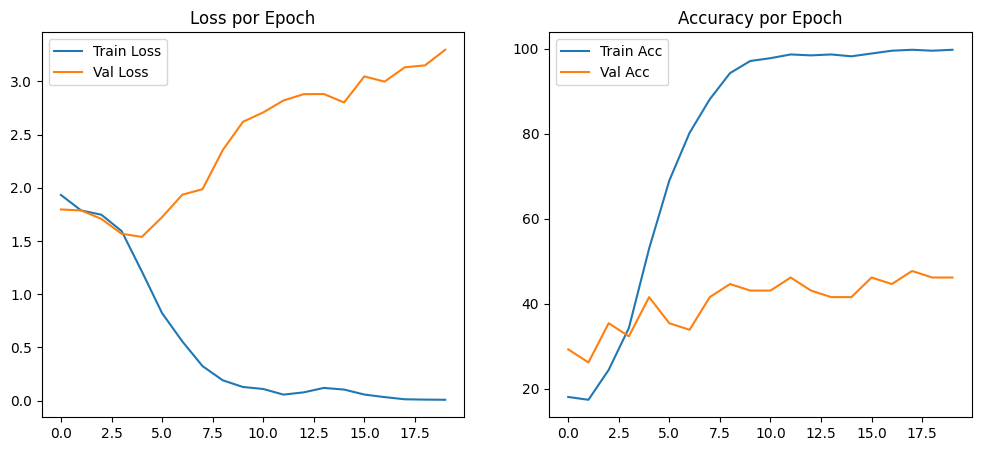

Accuracy del modelo en test: 48.09%


<Figure size 800x600 with 0 Axes>

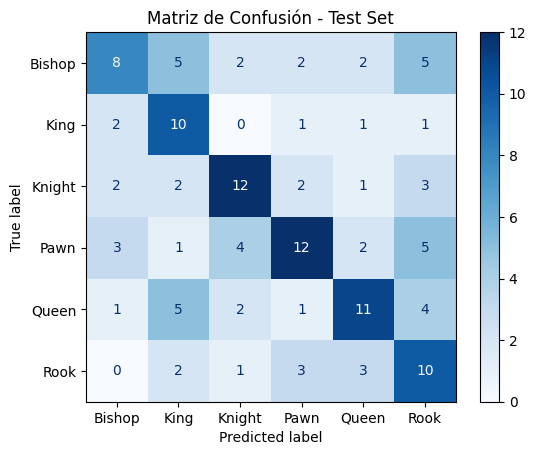

In [ ]:
# =============================
# GRAFICAS DE PROGRESO
# =============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.title('Loss por Epoch')

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.title('Accuracy por Epoch')
plt.show()

# =============================
# EVALUACIÓN FINAL EN TEST
# =============================
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy del modelo en test: {100 * correct / total:.2f}%')

# =============================
# MATRIZ DE CONFUSIÓN
# =============================
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
plt.figure(figsize=(8,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Test Set")
plt.show()

#### **10. RESULTADOS**
La red aprendió muy bien los datos de entrenamiento, pero no generaliza bien a nuevos datos (validación) debido a que es un modelo pequeño con pocos datos y sin técnicas de regularización más fuertes.

Gráfica de Loss y Accuracy:

Loss de entrenamiento → baja constantemente.

Loss de validación → aumenta después de algunas epochs.

Accuracy de validación → se estabiliza muy bajo (~40-50%).

Esto confirma overfitting: la red memoriza los ejemplos de entrenamiento pero no aprende patrones generalizables.